# Labelers precision

We will attempt to calculate a measure of the labelers attempt using a consensus criteria for determining the "true label" per object. This criteria will be the same used for training as of writing, which is to select the mode as the true label (only between elements with no data quality comments.)

## Loading Label information

First, we must download the label informartion which is hosted on a google drive folder, and consists of several .csv files. We've saved the files on a local folder which is represented in the variable "path" of the next cell. Some excel duplicates where found and manually removed from the folder. Now, we can gather the desired "fields" or columns from all this files and merge them into a pandas dataframe.

In [1]:
# get relevant relative directories, create folder for storing any generated files. 

from pathlib import Path
import os

# Set current directory for using relative paths

current_dir =  Path(globals()['_dh'][0])
project_dir =  Path(globals()['_dh'][0]).parent

try:
    os.mkdir(os.path.join(current_dir, '1.0-jrb-alternative-approach'))
except:
    print("Failed to create folder. Perhaps the folder already exists, or there's a permissions issue.")

Failed to create folder. Perhaps the folder already exists, or there's a permissions issue.


In [3]:
import pandas as pd

path = os.path.join(project_dir, r'data/raw/label_data')
fields = ['File Name', 'MJD', 'Target ID', 'DB ID' ,'Classification', 'Data Quality']

raw_labels_df = pd.DataFrame()

# We import all of the csv files and merge them in star_df

for filename in os.listdir(path):
    file_path = os.path.join(path, filename)
    df = pd.read_csv (file_path, usecols=fields)
    raw_labels_df = pd.concat([raw_labels_df, df], ignore_index=True)
print(raw_labels_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35253 entries, 0 to 35252
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Classification  35253 non-null  object
 1   DB ID           35253 non-null  int64 
 2   Data Quality    11158 non-null  object
 3   File Name       35253 non-null  object
 4   MJD             35253 non-null  int64 
 5   Target ID       35253 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 1.6+ MB
None


In [4]:
raw_labels_df

,Classification,DB ID,Data Quality,File Name,MJD,Target ID
0,WDA,21899,NaN,spec-15249-59265-04601916346-21899.png,59265,4601916346
1,sdX,23360,BLEND,spec-15301-59338-04602344336-23360.png,59338,4602344336
2,WDA,18900,SNR,spec-15113-59217-04538755416-18900.png,59217,4538755416
3,WDA,18575,NaN,spec-15086-59267-04474143209-18575.png,59267,4474143209
4,WD,20528,SNR,spec-15198-59269-04351438385-20528.png,59269,4351438385
...,...,...,...,...,...,...
35248,WDA,15895,SNR,spec-15011-59222-04399876473-15895.png,59222,4399876473
35249,WDA,20605,NaN,spec-15200-59324-04589320996-20605.png,59324,4589320996
35250,WDA,19388,NaN,spec-15193-59243-04594923329-19388.png,59243,4594923329
35251,DUNNO,19161,SNR,spec-15121-59212-04342114705-19161.png,59212,4342114705


We can see there is some NaN values in the Data Quality column from when no data quality comment was offered. For now, let's assume this data can be considererd OK, which is reasonable. 

Let's take a look at the label distribution.

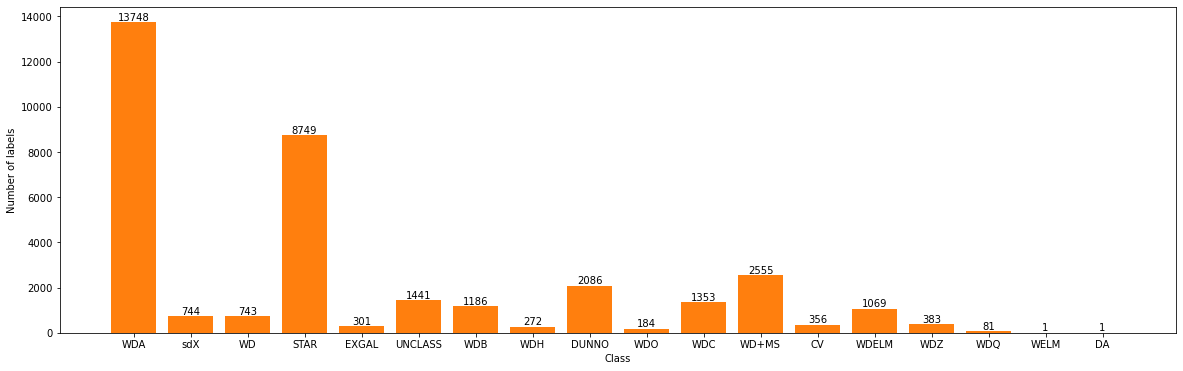

In [5]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# Plot bar graph of labels

counter = Counter(raw_labels_df['Classification'])
star_class = counter.keys()
star_counts = counter.values()
indexes = np.arange(len(star_class))
width = 0.7

fig, ax = plt.subplots(figsize=(20,6))

ax.bar(indexes, star_counts, width)
bars = ax.bar(indexes, star_counts)
ax.bar_label(bars)

plt.xlabel('Class')
plt.ylabel('Number of labels')
plt.xticks(indexes, labels=star_class)
plt.show()

We can see there's probably two mislabeled elements, WELM and DA. We can make the tag corrections now, and we will also change the NaN values in the Data Quality column by an 'OK' string.

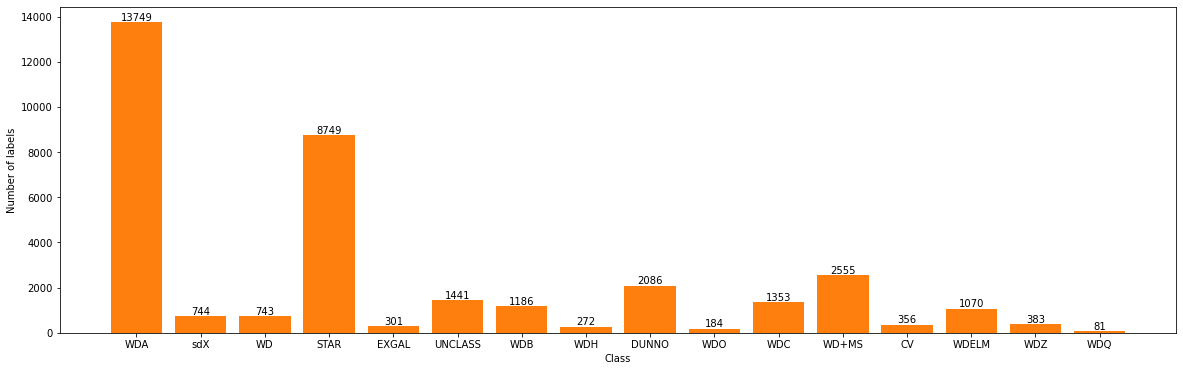

In [6]:
# Mislabeled elements correction

raw_labels_df.loc[raw_labels_df['Classification'] == 'WELM', 'Classification'] = 'WDELM'
raw_labels_df.loc[raw_labels_df['Classification'] == 'DA', 'Classification'] = 'WDA'


# Changing the NaNs data quality abscence of comment with an 'OK'

raw_labels_df['Data Quality'] = raw_labels_df['Data Quality'].fillna('OK')

# Plot bar graph of labels

counter = Counter(raw_labels_df['Classification'])
star_class = counter.keys()
star_counts = counter.values()

indexes = np.arange(len(star_class))
width = 0.7

fig, ax = plt.subplots(figsize=(20,6))

ax.bar(indexes, star_counts, width)
bars = ax.bar(indexes, star_counts)
ax.bar_label(bars)

plt.xlabel('Class')
plt.ylabel('Number of labels')
plt.xticks(indexes, labels=star_class)
plt.show()

We can know check the Data quality comments distribution

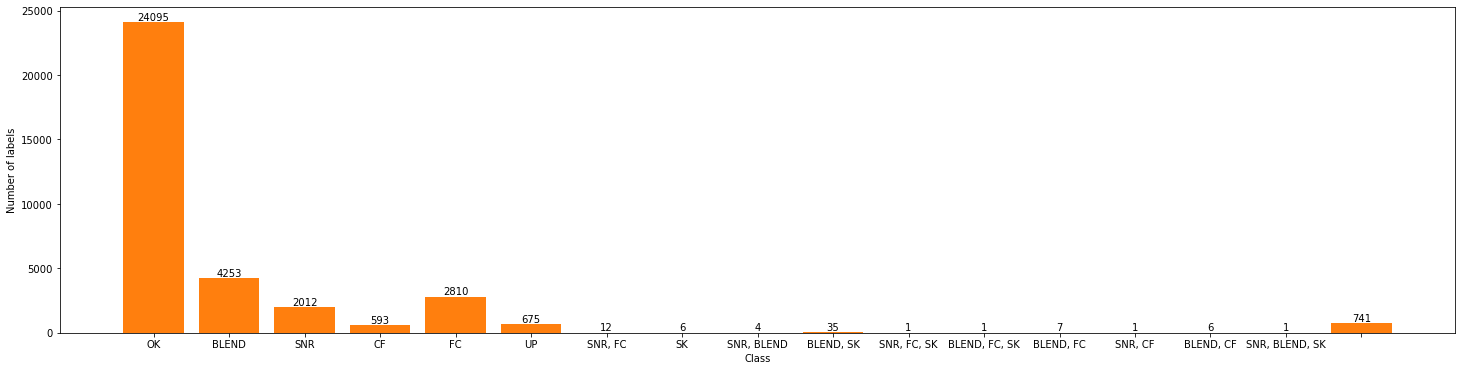

In [7]:
counter = Counter(raw_labels_df['Data Quality'])
star_class = counter.keys()
star_counts = counter.values()

# Plot bar graph of star Data Quality Comments using matplotlib

indexes = np.arange(len(star_class))
width = 0.7

fig, ax = plt.subplots(figsize=(25,6))

ax.bar(indexes, star_counts, width)
bars = ax.bar(indexes, star_counts)
ax.bar_label(bars)

plt.xlabel('Class')
plt.ylabel('Number of labels')
plt.xticks(indexes, labels=star_class)
plt.show()

We can see that, on the one side, there's multiple Data Quality Comments for a star minority, and that there is a misterious blank comment (or ' ' string comment), different from the 'OK' string (Previously NaNs). We will asume these tags can be labeled as 'OK' also, as they are classified samples with no (bad) data quality comments. 

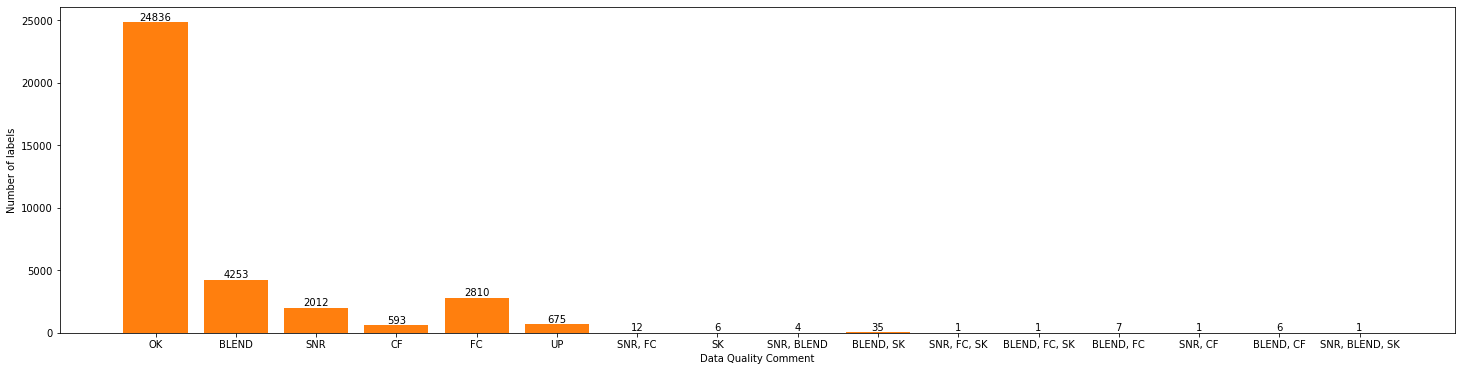

In [8]:
# change empty commentary by OK.

raw_labels_df.loc[raw_labels_df['Data Quality'] == ' ', 'Data Quality'] = 'OK'

counter = Counter(raw_labels_df['Data Quality'])
star_class = counter.keys()
star_counts = counter.values()

# Plot bar graph of star Data Quality Comments using matplotlib

indexes = np.arange(len(star_class))
width = 0.7

fig, ax = plt.subplots(figsize=(25,6))

ax.bar(indexes, star_counts, width)
bars = ax.bar(indexes, star_counts)
ax.bar_label(bars)

plt.xlabel('Data Quality Comment')
plt.ylabel('Number of labels')
plt.xticks(indexes, labels=star_class)
plt.show()

This looks better. Next, we'd like to find out how many of the same stellar objects are actually labeled, not counting repetitions for different observations.

In [9]:
target_id = raw_labels_df['Target ID']

# Duplicated values are marked as True, except the first element found, which is kept as False.

target_id.duplicated(keep='first').value_counts()

True     25349
False     9904
Name: Target ID, dtype: int64

So, there's actually 9904 unique stellar elements whit multiple observations, and thus, Data Quality Comments and Classifications may vary between each observation. This means we need to define a way to parse this data for the following ML algorithms. Let's explore a particular random element for illustration.

In [10]:
# Get data drom element with target ID 4342114705 

raw_labels_df.loc[raw_labels_df['Target ID'] == 4342114705]

,Classification,DB ID,Data Quality,File Name,MJD,Target ID
4158,STAR,19161,BLEND,spec-15121-59206-04342114705-19161.png,59206,4342114705
25514,STAR,19161,OK,spec-15121-59212-04342114705-19161.png,59212,4342114705
29241,DUNNO,19161,BLEND,spec-15121-59206-04342114705-19161.png,59206,4342114705
33146,STAR,19161,BLEND,spec-15121-59206-04342114705-19161.png,59206,4342114705
35251,DUNNO,19161,SNR,spec-15121-59212-04342114705-19161.png,59212,4342114705


What can we do we the data quality comments? Even if there were no comments, how do we decide the correct label for each element? these are the core issues. Let's define a simple pre-processing policy for the labels.

## Pre-processing Label information

Now we can focuse on an approach to pre-process label information for the upcoming ML algorithms. The approach I take here is to exclude all files with data quality issues first, meaning these will be considered as invalid information and will not be used for the upcoming machine laerning algorithms.

In [11]:
qlabels_df = raw_labels_df.copy()

qlabels_df.drop(qlabels_df[qlabels_df['Data Quality'] != 'OK'].index, inplace = True)

In [12]:
qlabels_df

,Classification,DB ID,Data Quality,File Name,MJD,Target ID
0,WDA,21899,OK,spec-15249-59265-04601916346-21899.png,59265,4601916346
3,WDA,18575,OK,spec-15086-59267-04474143209-18575.png,59267,4474143209
5,WDA,22243,OK,spec-15266-59306-04592699543-22243.png,59306,4592699543
6,WDA,19555,OK,spec-15165-59202-04545012720-19555.png,59202,4545012720
7,WD,20892,OK,spec-15221-59245-04306649216-20892.png,59245,4306649216
...,...,...,...,...,...,...
35242,STAR,20434,OK,spec-15288-59294-04552877469-20434.png,59294,4552877469
35244,STAR,20259,OK,spec-15195-59271-04543081849-20259.png,59271,4543081849
35246,STAR,20046,OK,spec-15285-59304-04550841319-20046.png,59304,4550841319
35249,WDA,20605,OK,spec-15200-59324-04589320996-20605.png,59324,4589320996


In [13]:
# Let's explore how many unique stellar objects we have left.

qlabels_df['Target ID'].duplicated(keep='first').value_counts()

True     16723
False     8113
Name: Target ID, dtype: int64

In [14]:
# Let's look at element 4553795050 as an example.

qlabels_df.loc[qlabels_df['Target ID'] == 4553795050]

,Classification,DB ID,Data Quality,File Name,MJD,Target ID
4234,WDB,19293,OK,spec-15127-59190-04553795050-19293.png,59190,4553795050
12013,WDC,19293,OK,spec-15190-59248-04553795050-19293.png,59248,4553795050
17274,WDA,19293,OK,spec-15190-59273-04553795050-19293.png,59273,4553795050
18200,WDB,19293,OK,spec-15127-59219-04553795050-19293.png,59219,4553795050
19215,WDC,19293,OK,spec-15190-59248-04553795050-19293.png,59248,4553795050
28327,WDB,19293,OK,spec-15127-59219-04553795050-19293.png,59219,4553795050
33724,WDC,19293,OK,spec-15190-59273-04553795050-19293.png,59273,4553795050
34566,WDB,19293,OK,spec-15190-59267-04553795050-19293.png,59267,4553795050
34673,WDB,19293,OK,spec-15127-59190-04553795050-19293.png,59190,4553795050
35240,WDC,19293,OK,spec-15190-59248-04553795050-19293.png,59248,4553795050


Now, we can focus on how to resolve the fact that a same object can have several different classification labels from different evaluations, and each may be from a different observation (as reflected by the Modified Julian Date number, or MJD, for example), but not necesarilly (there can be discenting labels for exactly the same data, probably made by different labelers). One option could be to consider the official classification Label as the most voted one, resolving ties to either way.

In [15]:
# The following statement will return most applied label for each element, given the target ID field, as a one dimensional list.

qlabels_df.loc[qlabels_df['Target ID'] == 4553795050]['Classification'].mode().to_list()

['WDB']

For simplicity, in this first run, I have decided to use ONLY ONE of the data files associated to each unique Target ID, and it has to come from a file that produced a label matching the "most voted" one by the evaluators. This means we will use only one .dat file per object when training the ML classifier.